In [1]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [2]:
import os, re, sys, traceback, csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics\\sandbox'

In [3]:
import generator_core as core
from aspect_midnight import Midnight, Word2Vec_SkipGram, ArrayToDatasetForW2V

In [4]:
create_dataset = False

In [5]:
try:
    # print(core.genius_lyrics.file_name)
    ds_genius = lambda: core.genius_lyrics.open_as_df()

    if create_dataset:
        for ds_batch in ds_genius():
            display(ds_batch.head())
            break
except:
    traceback.print_exc()

In [6]:
try:
    batch_count = 0
    genres = set()
    if create_dataset and False:
        for ds_batch in ds_genius():
            batch_count += 1
            genres.update(ds_batch['tag'].unique())
    else:
        batch_count = 103
        genres = {'rap', 'rb', 'pop', 'country', 'rock', 'misc'}
    print(genres)
    print(batch_count)
except:
    traceback.print_exc()

{'rb', 'pop', 'country', 'rap', 'misc', 'rock'}
103


In [7]:
try:
    total_subset_size = 100000
    total_group_size = total_subset_size // len(genres) + 1
    max_songs_per_artist = 50

    if create_dataset:
        genre_groups = {}
        artist_counts = {}

        pbar = tqdm(total=batch_count)
        for ds_batch in ds_genius():
            pbar.update(1)
            ds_batch = ds_batch.drop(columns=['views', 'features', 'language_cld3', 'language_ft'])
            ds_batch = ds_batch[ds_batch['language'] == 'en'].sample(frac=1)
            ds_batch['length'] = ds_batch['lyrics'].apply(len)
            ds_batch = ds_batch[(ds_batch['length'] >= 1000) & (ds_batch['length'] <= 3000)]

            for genre in genres:
                group = genre_groups.get(genre, pd.DataFrame())
                if len(group) >= total_group_size: continue

                ds_batch = ds_batch[ds_batch['tag'] == genre]
                for artist, a_group in ds_batch.groupby('artist'):
                    existing_count = artist_counts.get(artist, 0)
                    if existing_count >= max_songs_per_artist: continue
                    new_sample = min(len(a_group), max_songs_per_artist - existing_count)
                    subset = a_group.sample(new_sample).drop(columns=['length'])
                    group = pd.concat([group, subset])
                    artist_counts[artist] = existing_count + new_sample

                if len(group) >= total_group_size: group = group.sample(total_group_size)
                genre_groups[genre] = group

            if all([len(group) >= total_group_size for group in genre_groups.values()]): break

        for genre, group in genre_groups.items():
            print(genre, len(group))

        print("Unique Artists", len(artist_counts))
        print("Avg Songs/Artists", np.mean(list(artist_counts.values())))

    else:
        print("misc 16667\nrap 16667\nrb 16667\npop 16667\ncountry 16667\nrock 16667\nUnique Artists 37648\nAvg Songs/Artists 2.8438429664258393")
except:
    traceback.print_exc()

misc 16667
rap 16667
rb 16667
pop 16667
country 16667
rock 16667
Unique Artists 37648
Avg Songs/Artists 2.8438429664258393


In [8]:
try:
    if create_dataset:
        ds_subset = pd.concat(list(genre_groups.values())).sample(frac=1)
        ds_subset.to_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
        display(ds_subset.head())
        del genre_groups
    else:
        ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
        display(ds_subset.head())
except:
    traceback.print_exc()

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [9]:
try:
    _t = ds_subset.sample(1)
    print("INDEX: ", _t.index[0])
    print(_t['lyrics'].values[0])
except:
    traceback.print_exc()

INDEX:  94393
Everything about European life suggests a much more laid-back lifestyle, even things like sirens. You know, here our sirens are very functional

[British two-tone siren plays]

It sort of says “Come-On Come-On Outthe-Way Outthe-Way. Whataremy-jobsworth.”

[British two-tone siren plays, descending in note at the end]

Which to me denotes disappointment

[British two-tone siren plays, descending in note at the end]

Interestingly, you never hear them go the other way do you?

[British two-tone siren plays, ascending in note at the end]

They never do that, do they?

“Here he comes, look, oh there he goes up!”
[British two-tone siren plays, ascending in note at the end]
Because that would be defying the laws of physics, wouldn’t it? That would be an ambulance attending an emergency in another dimension

[British two-tone siren plays, ascending in note at the end at holding said note as sci-fi effects play]
[Bailey speaks alien gibberish]

Here, very functional
[British two-t

In [10]:
# There are named speech tags of form "(Devyn)" and "(Simon)"
# Other conventions like "[Hook]" and "[Pre-Hook]"
# Some crazy format issues too like "[Hook ]"
# Sometimes the first line is the song title
# And then there is just text in [] like "[See, everybody ...211 chars total... the same fr]"
# There are also numbered versions like "[Verse 1]"
# 4314672: Wow, there are even URLS like "https://www.rapidbooster.net/". In fact there is no song at all
# 101494 : has "[Verse 1: Michael Jackson]"
# 46815  : has "[Chorus: Slug and Murs]", "[Murs]", "[Slug]"
# 28520  : has "[Frank Sinatra sample]", "[Hook 2X][Frank Sinatra](Kids)", and other text in () and []
# 8889   : has an unclosed [ in the start
# 1459482: has both "(Chorus)" and "Chorus:"
# 2944086: has "[October 31st, 2004]"
# 22005  : has it's verses separated as I, II, III...

In [11]:
try:
    midnight = Midnight(ds_subset)
except:
    traceback.print_exc()

Loaded Cache for Midnight._prepare_ds_data.cached
Loaded Cache for Midnight._get_custom_tokens.cached
Loaded Cache for Midnight._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp\lyrics_sp.model
Fraction:  1/10    Epoch:  0/ 1    Train Loss: 9.70    TTS: 5.62    ETA: 35148.54
Fraction:  2/10    Epoch:  0/ 1    Train Loss: 9.53    TTS: 8.83    ETA: 27576.52
Fraction:  3/10    Epoch:  0/ 1    Train Loss: 9.21    TTS: 11.60    ETA: 24164.11
Fraction:  4/10    Epoch:  0/ 1    Train Loss: 8.79    TTS: 14.64    ETA: 22863.88
Fraction:  5/10    Epoch:  0/ 1    Train Loss: 8.43    TTS: 17.38    ETA: 21707.93
Fraction:  6/10    Epoch:  0/ 1    Train Loss: 7.80    TTS: 20.10    ETA: 20922.15
Fraction:  7/10    Epoch:  0/ 1    Train Loss: 7.38    TTS: 22.82    ETA: 20354.23
Fraction:  8/10    Epoch:  0/ 1    Train Loss: 6.85    TTS: 25.55    ETA: 19936.05
Fraction:  9/10    Epoch:  0/ 1    Train Loss: 6.49    TTS: 28.24    ETA: 19586.41
Fraction: 10/10    Epoch:  0/ 1    Tra

In [12]:
try:
    # for sample in ds_subset[ds_subset['id'] == 1856105].itertuples():
    for sample in ds_subset.sample(1).itertuples():
        print("INDEX", sample.id)
        print("ORIGINAL")
        print(sample.lyrics)
        print("PROCESSED")
        print(midnight.clean_text(sample.lyrics))
except:
    traceback.print_exc()

INDEX 7211912
ORIGINAL
Malicious resplendence
A master of lies
Give me everything you owe me your life
My fuel is my hatred
Unforgiving contempt
For the waste of life you feebly attempt
I pray on your weakness exposing your spine
You cower at my feet and hold me divine
Driven by hatred I rule through fear
I am the master of all you hold dear
Architects of murder sadistic and cruel
You're on this planet for only my use
My rivals exiled torturеd and killed
Forced suicide a sеxual thrill
Scholars beheaded some buried alive
You only know when it comes from my mind
Merciless ruler sexually depraved
Piteous raping of all the enslaved
A View askew
So corrupt
A crooked smile I gain your trust
Give a little
Then take it back
Then take yours and fucking laugh
I am your God
I own your soul
With your life you'll pay what you owe
Nothing left, your all spent
I keep taking
Never relent
Rampage cities
Tear them down
Destroy anyone who threatens the crown
Avenge the curse
Of a paranoid mind
Flay the s

In [14]:
try:
    print(midnight.custom_tokens)
except:
    traceback.print_exc()

{'<SONG_END>', '<INTERLUDE>', '<SONG_START>', '<OUTRO>', '<BRIDGE>', '<INTRO>', '<HOOK>', '<STANZA>', '<VERSE>', '<CHORUS>'}


In [17]:
try:
    print(midnight.feature_names)
    # WTF is this?
except:
    traceback.print_exc()

["'" "''" "''i" ... '지금' 'ﬁnd' '𝘺𝘰𝘶']


In [15]:
try:
    # for sample in ds_subset[ds_subset['id'] == 1856105].itertuples():
    lengths = ds_subset['lyrics'].apply(len)
    print(lengths.min(), lengths.max(), lengths.mean())
    del lengths
    # TODO: 10 random windows of size 20 per song
except:
    traceback.print_exc()

1000 3000 1670.2838243235135


In [19]:
try:
    display(midnight.annotate_text(2))
except:
    traceback.print_exc()

Annotation(text_id=2, genre='pop', keywords=['pull', 'blame', 'love', 'played', 'falling'])

In [20]:
try:
    print("Vocab Size: ", midnight.vocabulary.vocab_size())
    dat = midnight.tokenize_text("pneumonoultramicroscopicsilicovolcanoconiosis")
    print(dat)
except:
    traceback.print_exc()

Vocab Size:  16000
[14617, 11135, 3890, 3445, 10503, 14, 1640, 10636, 14, 7429, 1640, 2981, 8764, 7737, 3402, 626, 12244]


In [21]:
try:
    word2vec = midnight.embedder
    print(word2vec)
except:
    traceback.print_exc()

Word2Vec_SkipGram(
  (embeddings): Embedding(16000, 256, max_norm=1.0)
  (linear): Linear(in_features=256, out_features=16000, bias=True)
)


In [22]:
try:
    midnight.embedder.trainer.dataset_fraction = None
    for pg in word2vec.trainer.optimizer.param_groups:
        pg['lr'] = 0.003
except:
    traceback.print_exc()

In [23]:
try:
    word2vec.train_model()
except:
    traceback.print_exc()

Epoch:  0/ 1    Train Loss: 5.49    TTS: 2.78    ETA: 17375.33
Epoch:  0/ 1    Train Loss: 5.49    TTS: 5.45    ETA: 17020.66
Epoch:  0/ 1    Train Loss: 5.40    TTS: 8.10    ETA: 16877.42
Epoch:  0/ 1    Train Loss: 5.41    TTS: 10.71    ETA: 16722.79
Epoch:  0/ 1    Train Loss: 5.63    TTS: 13.45    ETA: 16800.57
Epoch:  0/ 1    Train Loss: 5.49    TTS: 16.23    ETA: 16894.25
Epoch:  0/ 1    Train Loss: 5.72    TTS: 18.94    ETA: 16894.09
Epoch:  0/ 1    Train Loss: 5.29    TTS: 21.60    ETA: 16852.47
Epoch:  0/ 1    Train Loss: 5.36    TTS: 24.21    ETA: 16793.56
Epoch:  0/ 1    Train Loss: 5.29    TTS: 26.86    ETA: 16764.63
Epoch:  0/ 1    Train Loss: 5.28    TTS: 29.52    ETA: 16747.24
Epoch:  0/ 1    Train Loss: 6.00    TTS: 32.13    ETA: 16704.22
Epoch:  0/ 1    Train Loss: 5.36    TTS: 34.73    ETA: 16665.15
Epoch:  0/ 1    Train Loss: 5.32    TTS: 37.46    ETA: 16688.00
Epoch:  0/ 1    Train Loss: 5.11    TTS: 40.13    ETA: 16683.27
Epoch:  0/ 1    Train Loss: 5.31    TTS: 42

Traceback (most recent call last):
  File "C:\Users\mcxiv\AppData\Local\Temp\ipykernel_4280\848437435.py", line 2, in <module>
    word2vec.train_model()
    ~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\aspect_midnight\word2vec.py", line 103, in train_model
    self.trainer.train()
    ~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 181, in train
    self._train_step(epoch)
    ~~~~~~~~~~~~~~~~^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 214, in _train_step
    loss.backward()
    ~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\_tensor.py", line 631, in backward
    torch.autograd.backward(
    ~~~~~~~~~~~~~~~~~~~~~~~^
        self, gradient, retain_graph, create_graph, inputs=inputs
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Berylliu

In [24]:
try:
    timers = word2vec.trainer.timer.timers
    for key in timers:
        print(key, timers[key].average)
except:
    traceback.print_exc()

train 33.658709100000124
_train_step 33.545207900000605
train_dataloader 0.010552253259354398
batch 2.6222688590277827


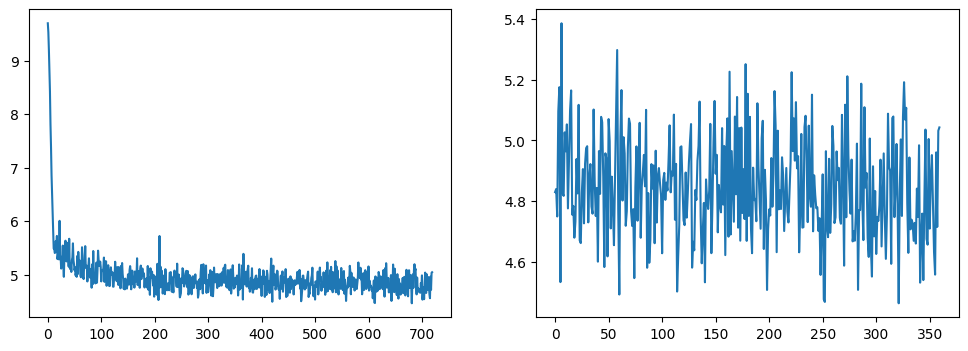

In [27]:
try:
    loss = word2vec.trainer.loss
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].plot(loss['train.batch'])
    axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
    plt.show()
except:
    traceback.print_exc()

In [29]:
try:
    rewrite_embedder_cache = True
    if rewrite_embedder_cache:
        flight = 'Midnight._prepare_embedder.cached'
        for file in ['bone', 'pkl']:
            file = os.path.join('temp', f'{flight}.{file}')
            if os.path.exists(file): os.remove(file)
        core.key_cached('cached', lambda: word2vec, group='Midnight._prepare_embedder')
except:
    traceback.print_exc()

In [31]:
try:
    with torch.no_grad():
        print(word2vec(torch.tensor([midnight.tokenize_text('love')])))
except:
    traceback.print_exc()

tensor([[[ 2.1630, -6.8972, -6.8958,  ..., -6.9237, -6.9265, -6.9269]]])


In [32]:
try:
    _embeds = midnight.embed_tokens(1)
    print(_embeds.shape)
except:
    traceback.print_exc()

(785, 16000)


In [ ]:
try:
    pass
except:
    traceback.print_exc()

In [ ]:
try:
    pass
except:
    traceback.print_exc()

In [ ]:
try:
    pass
except:
    traceback.print_exc()